In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import Necessary Python modules

In [2]:
#------ Import Necessary Python Modules -----
import numpy as np
import requests
from PIL import Image
from io import BytesIO
from datasets import load_dataset
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
import cv2
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import os
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE



In [3]:
def Preprocess(img):
    resized = cv2.resize(img, (128, 128))
    # Denoising
    # denoised = cv2.fastNlMeansDenoisingColored(resized, None, h=10, hColor=10, templateWindowSize=7, searchWindowSize=21)
    # Normalize
    normalized = resized.astype('float32') / 255.0
    return normalized

In [4]:
# ---------- Loading Data -------------------

# Medical Images from Huggingface
medical_images = load_dataset("tanzuhuggingface/brainmri")
Medical_img = []
for sample in medical_images['train']:
  img_data = sample['image']
  if isinstance(img_data, str) and img_data.startswith("http"):
    img = Image.open(BytesIO(requests.get(img_data).content))
  else:
    img = img_data
  Medical_img.append(np.array(img))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:

# labelling the data
All_Images = []
All_Labels = []
for i in range(len(Medical_img)):
  preprocessed = Preprocess(Medical_img[i])
  All_Images.append(preprocessed)
  All_Labels.append(0)
# Nonmedical Images from CIFAR10
(Non_Medical_img, _), (_, _) = cifar10.load_data()
Non_Medical_img = Non_Medical_img[:5000]
for j in range(Non_Medical_img.shape[0]):
  preprocessed = Preprocess(Non_Medical_img[j])
  All_Images.append(preprocessed)
  All_Labels.append(1)


MODEL

In [6]:
def CNN_Model(xtrain, xtest, ytrain, ytest):
    # sequential model
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
        MaxPooling2D(2, 2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2, 2),

        Flatten(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    #--- model Arch
    model.summary()

    # ---Train Model ---
    # model.fit(datagen.flow(xtrain, ytrain, batch_size=32),
    #           epochs=5,
    #           validation_data=(xtest, ytest))
    model.fit(xtrain, ytrain, batch_size=32,
              epochs=10,
              validation_data=(xtest, ytest))

    # --- Evaluation ---
    y_pred = (model.predict(xtest) > 0.5).astype("int32")

    print("\nConfusion Matrix:")
    print(confusion_matrix(ytest, y_pred))

    print("\nClassification Report:")
    print(classification_report(ytest, y_pred))

    # --- Save model weights ---
    model.save("/content/drive/MyDrive/MedicalImageClassifier/cnn_model.h5")
    print("\nModel saved as cnn_binary_model.h5")


In [7]:
# train test split
xtrain, xtest, ytrain, ytest = train_test_split(np.array(All_Images), np.array(All_Labels), test_size=0.2, random_state=42)


# data balancing
xtrain_flat = xtrain.reshape((xtrain.shape[0], -1))
smote = SMOTE(random_state=42)
xtrain, ytrain = smote.fit_resample(xtrain_flat, ytrain)
xtrain = xtrain.reshape((-1, 128, 128, 3))

# # To reduce complexity of the model we use less amount of data,
# # approach with Data Augmentation
# datagen = ImageDataGenerator(
#     rotation_range=10,
#     zoom_range=0.1,
#     horizontal_flip=True
# )
# datagen.fit(xtrain)

In [8]:
CNN_Model(xtrain, xtest, ytrain, ytest)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,705,921 (14.14 MB)

 Trainable params: 3,705,921 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - accuracy: 0.9597 - loss: 0.1128 - val_accuracy: 0.9992 - val_loss: 0.0038
Epoch 2/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9978 - loss: 0.0073 - val_accuracy: 1.0000 - val_loss: 4.9943e-04
Epoch 3/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9998 - loss: 8.7345e-04 - val_accuracy: 1.0000 - val_loss: 1.1558e-04
Epoch 4/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 1.0000 - loss: 4.0409e-05 - val_accuracy: 1.0000 - val_loss: 2.8689e-05
Epoch 5/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 1.0000 - loss: 1.8819e-05 - val_accuracy: 1.0000 - val_loss: 1.8207e-05
Epoch 6/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 1.0000 - loss: 9.2579e-06 - val_accuracy: 1.0000 - val_loss: 1.0717e-05
Epoch 7/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 1.0000 - loss: 8.0396e-06 - val_accuracy: 1.0000 - val_loss: 8.3318e-06
Epoch 8/10
252/252 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


Confusion Matrix:
[[313   0]
 [  0 973]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       313
           1       1.00      1.00      1.00       973

    accuracy                           1.00      1286
   macro avg       1.00      1.00      1.00      1286
weighted avg       1.00      1.00      1.00      1286


Model saved as cnn_binary_model.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


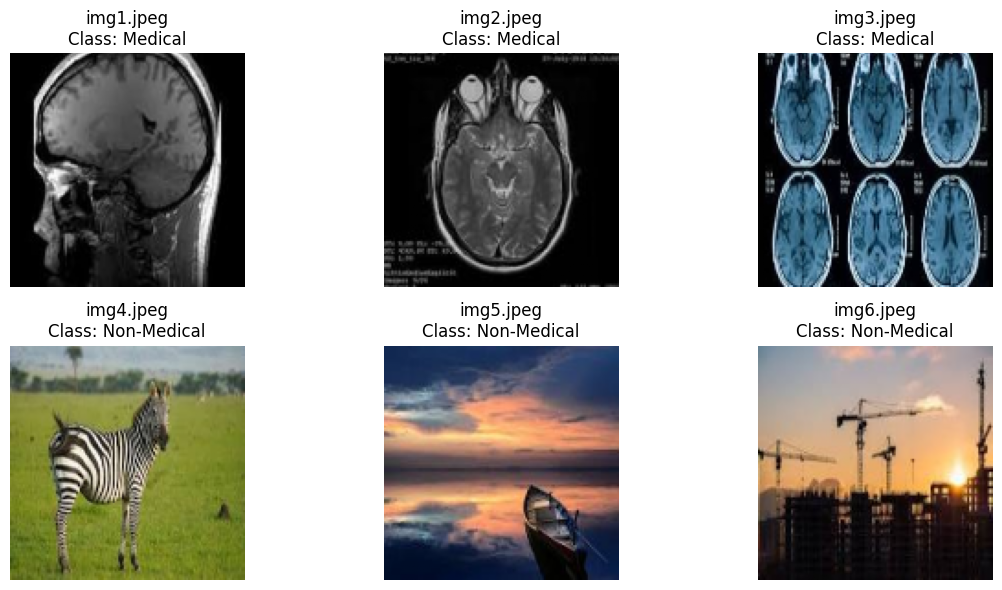

In [9]:

test_path = '/content/drive/MyDrive/MedicalImageClassifier/Test'

model = load_model('/content/drive/MyDrive/MedicalImageClassifier/cnn_model.h5')

# Load and preprocess images
All_Images = []
image_names = []
for img_name in os.listdir(test_path):
    img_path = os.path.join(test_path, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, (128, 128))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        All_Images.append(img)
        image_names.append(img_name)

# Prepare images for model
X_test = np.array(All_Images) / 255.0  # normalize
X_test_input = X_test.reshape(-1, 128, 128, 3)

# Predict
predictions = model.predict(X_test_input)
predicted_labels = (predictions > 0.5).astype(int).flatten()  # binary classification

# Label map
label_map = {0: 'Medical', 1: 'Non-Medical'}

# Display predictions
plt.figure(figsize=(12, 6))
for i in range(len(X_test)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_test[i])
    plt.title(f"{image_names[i]}\nClass: {label_map[predicted_labels[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()
